# 4장 1강: 단순선형회귀 이론 — 실습문제

## 실습 목표

- 최소제곱법의 공식을 이용해 단순선형회귀의 기울기와 절편을 직접 계산합니다.
- 회귀계수, 예측값, 잔차, SSE, SST, 결정계수 $R^2$의 의미를 설명합니다.
- 회귀선과 잔차 플롯을 함께 확인하여 모델의 설명력과 적합 타당성을 평가합니다.

## 실습 환경 / 데이터

- Python, NumPy, pandas, Matplotlib
- `ames_housing(1).csv`
- 주요 변수: `SalePrice`, `GrLivArea`, `YearBuilt`
- 이번 강의는 회귀 원리를 확인하는 과정이므로 회귀계수와 평가지표를 NumPy로 직접 계산합니다.

## 실습 준비

아래 셀을 실행하여 데이터를 불러오고 데이터 크기, 결측치, 컬럼을 확인하세요.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'

data_candidates = [
    Path("ames_housing(1).csv"),
    Path("ames_housing.csv"),
    Path("upload/ames_housing(1).csv"),
]
data_path = next((path for path in data_candidates if path.exists()), None)

if data_path is None:
    raise FileNotFoundError("ames_housing CSV 파일을 노트북과 같은 폴더에 넣어주세요.")

df = pd.read_csv(data_path)

print(f"데이터 크기: {df.shape[0]}행, {df.shape[1]}열")
print("전체 결측치 수:", int(df.isna().sum().sum()))
print("컬럼:", df.columns.tolist())
df.head()


데이터 크기: 1460행, 10열
전체 결측치 수: 0
컬럼: ['SalePrice', 'GrLivArea', 'LotArea', 'OverallQual', 'KitchenQual', 'CentralAir', 'HeatingQC', 'PavedDrive', 'Neighborhood', 'YearBuilt']


,SalePrice,GrLivArea,LotArea,OverallQual,KitchenQual,CentralAir,HeatingQC,PavedDrive,Neighborhood,YearBuilt
0,208500,1710,8450,7,Gd,Y,Ex,Y,CollgCr,2003
1,181500,1262,9600,6,TA,Y,Ex,Y,Veenker,1976
2,223500,1786,11250,7,Gd,Y,Ex,Y,CollgCr,2001
3,140000,1717,9550,7,Gd,Y,Gd,Y,Crawfor,1915
4,250000,2198,14260,8,Gd,Y,Ex,Y,NoRidge,2000


---

## 필수 1. 생활면적으로 매매가격을 설명하는 회귀직선 구하기

`GrLivArea`를 독립변수 $x$, `SalePrice`를 종속변수 $y$로 사용하여 최소제곱 회귀직선을 직접 구하세요.

### 수행 요구사항

1. 두 변수의 결측치를 제거한 분석용 데이터를 만드세요.
2. $x$와 $y$의 평균을 계산하세요.
3. 아래 공식을 이용하여 기울기 $\beta_1$과 절편 $\beta_0$를 계산하세요.

$$
\beta_1 = \frac{\sum (x_i-\bar{x})(y_i-\bar{y})}{\sum (x_i-\bar{x})^2},
\qquad
\beta_0 = \bar{y}-\beta_1\bar{x}
$$

4. 회귀식을 출력하고, 생활면적이 1,500일 때의 매매가격을 예측하세요.
5. 산점도 위에 회귀직선을 그리세요.

### 질문

- 기울기 $\beta_1$은 이 데이터에서 무엇을 의미하나요?
- 절편 $\beta_0$는 무엇을 의미하며, 현실적으로 그대로 해석해도 되나요?
- 최소제곱법은 어떤 기준으로 이 회귀직선을 선택하나요?


[평균]
x 평균 : 1515.464
y 평균 : 180921.196

[회귀계수]
기울기 beta1 : 107.130
절편 beta0 : 18569.026

[회귀식]
SalePrice = 18569.026 + 107.130 × GrLivArea

[예측]
GrLivArea가 1500일 때 예상 SalePrice : 179,264.564


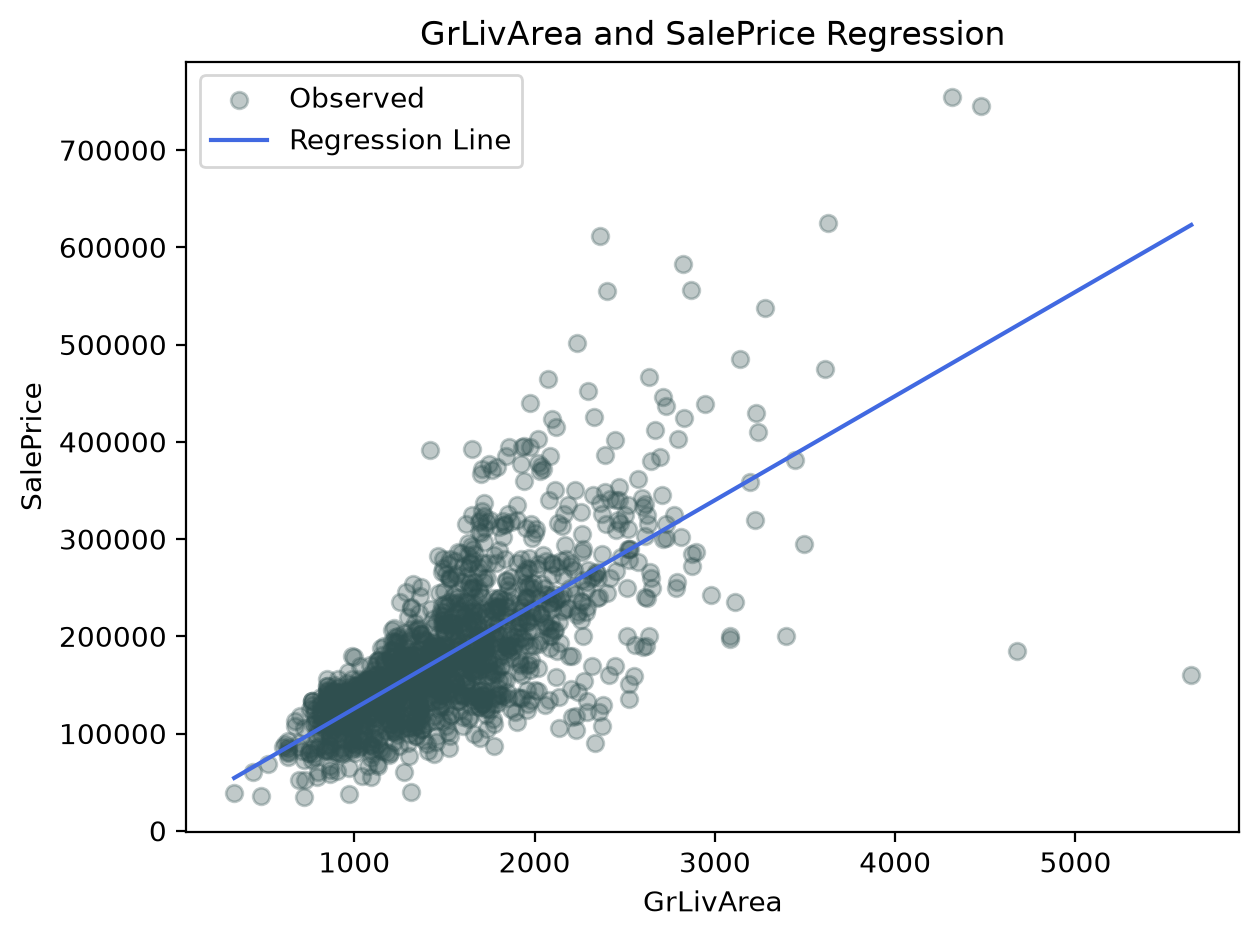

In [2]:
# 여기에 코드를 작성하세요.

plt.rcParams['axes.unicode_minus'] = False # 마이너스 부호 깨짐 방지

# 1. 결측치 제거
reg_df = df[['GrLivArea', 'SalePrice']].dropna()

x = reg_df['GrLivArea']
y = reg_df['SalePrice']


# 2. x, y 평균 계산
x_mean = x.mean()
y_mean = y.mean()

print('[평균]')
print(f'x 평균 : {x_mean:.3f}')
print(f'y 평균 : {y_mean:.3f}')


# 3. 기울기 beta1, 절편 beta0 계산
beta1 = ((x - x_mean) * (y - y_mean)).sum() / ((x - x_mean) ** 2).sum()
beta0 = y_mean - beta1 * x_mean

print('\n[회귀계수]')
print(f'기울기 beta1 : {beta1:.3f}')
print(f'절편 beta0 : {beta0:.3f}')


# 4. 회귀식 및 GrLivArea=1500일 때 예측
pred_1500 = beta0 + beta1 * 1500

print('\n[회귀식]')
print(f'SalePrice = {beta0:.3f} + {beta1:.3f} × GrLivArea')

print('\n[예측]')
print(f'GrLivArea가 1500일 때 예상 SalePrice : {pred_1500:,.3f}')


# 5. 산점도 + 회귀직선
plt.scatter(x, y, alpha=0.3, color='darkslategray', label='Observed')

# 회귀직선을 그리기 위한 x값
x_line = np.linspace(x.min(), x.max(), 100)

# 회귀식으로 예측한 y값
y_line = beta0 + beta1 * x_line

plt.plot(x_line, y_line, color='royalblue', label='Regression Line')

plt.xlabel('GrLivArea')
plt.ylabel('SalePrice')
plt.title('GrLivArea and SalePrice Regression')
plt.legend()

plt.tight_layout()
plt.show()

### 질문

- 기울기 $\beta_1$은 이 데이터에서 무엇을 의미하나요?
    - 생활면적이 1단위 증가할 때마다 모델이 예측하는 매매가격이 평균적으로 약 107.13만큼 증가한다는 의미

- 절편 $\beta_0$는 무엇을 의미하며, 현실적으로 그대로 해석해도 되나요?
    - 절편은 생활면적이 0(없는)인 주택이어도 약 18569.026달러를 지불해야한다.
    - 면적이 0인 주택은 관측범위나 현실적 분석 대상과는 거리가 있기 때문에 과도한 해석을 피해야한다.

- 최소제곱법은 어떤 기준으로 이 회귀직선을 선택하나요?
    - 잔차의 제곱해 모두 더한 SSE값이 가장 작아지는 기울기와 절편을 선택한다.

---

## 필수 2. 결정계수와 잔차로 회귀모델 평가하기

필수 1에서 구한 `beta0`, `beta1`, `x`, `y`를 이용하여 모델의 설명력과 잔차 분포를 평가하세요.

### 수행 요구사항

1. 예측값 $\hat{y}$과 잔차 $e=y-\hat{y}$를 계산하세요.
2. SSE와 SST를 계산한 뒤 $R^2=1-SSE/SST$를 구하세요.
3. 잔차의 평균과 평균절대잔차(MAE)를 계산하세요.
4. 예측값을 x축, 잔차를 y축으로 하는 잔차 플롯을 그리세요. $y=0$ 기준선을 표시하세요.
5. 절대잔차가 가장 큰 관측치의 생활면적, 실제가격, 예측가격, 잔차를 출력하세요.

### 질문

- $R^2$은 이 모델에서 무엇을 의미하나요?
- 잔차 평균이 0에 가깝다는 사실만으로 좋은 모델이라고 판단할 수 있나요?
- 잔차 플롯에서 오차의 폭과 극단적인 잔차는 어떻게 보이나요?
- 회귀계수, $R^2$, 잔차를 종합할 때 이 모델은 매매가격을 충분히 설명한다고 볼 수 있나요?


[예측값 , 잔차]
잔차 평균 : 0.000

[모델 평가]
SSE : 4,584,171,086,113.130
SST : 9,207,911,334,609.977
R² : 0.502

[잔차 평가]
잔차 평균 : 0.000
MAE : 37,638.729


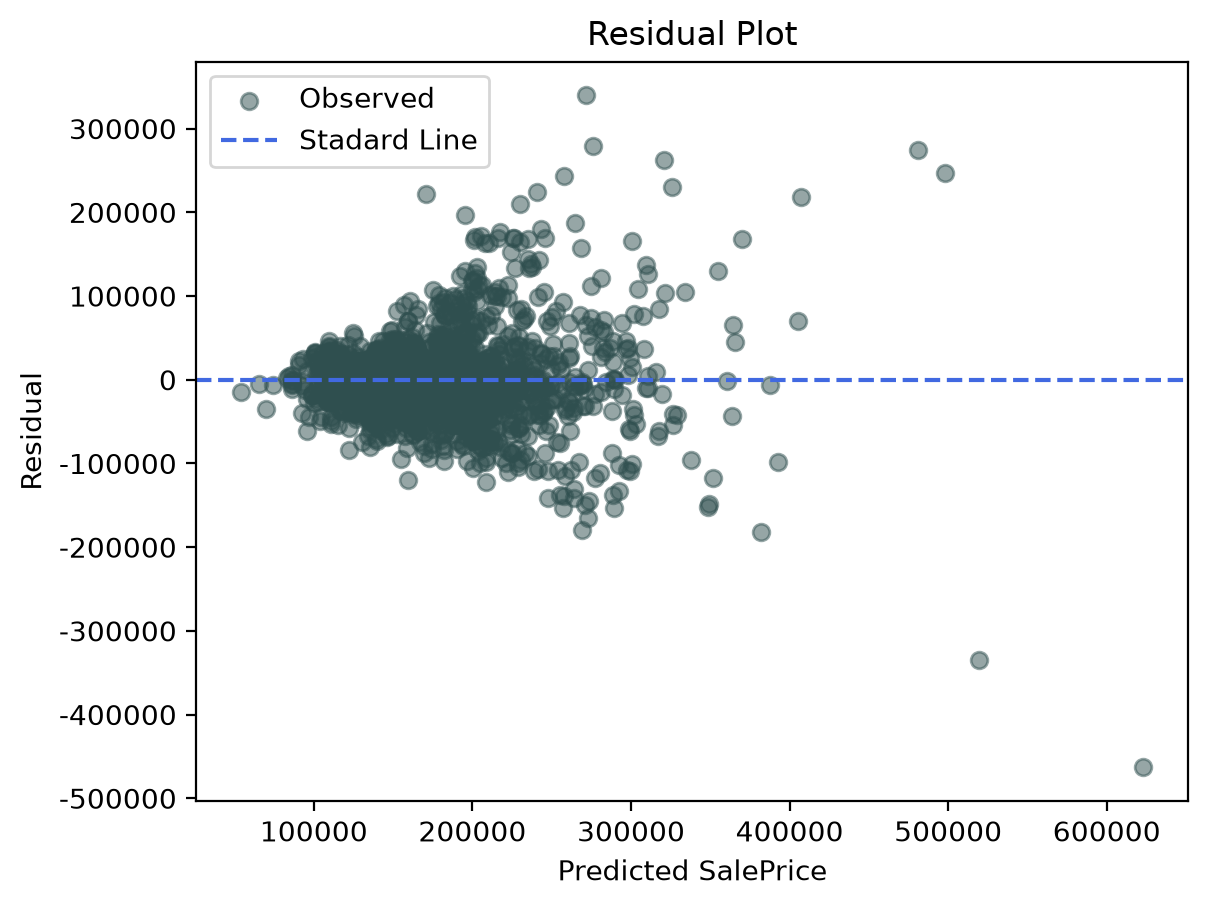


[절대잔차가 가장 큰 관측치]
생활면적 : 5,642.000
실제가격 : 160,000.000
예측가격 : 622,998.511
잔차 : -462,998.511


In [3]:
# 여기에 코드를 작성하세요.

# 1. 예측값과 잔차 계산
y_pred = beta0 + beta1 * x
residual = y - y_pred

print('[예측값 , 잔차]')
print(f'잔차 평균 : {residual.mean():,.3f}')


# 2. SSE, SST, R² 계산
SSE = ((y - y_pred) ** 2).sum()
SST = ((y - y.mean()) ** 2).sum()

r_squared = 1 - (SSE / SST)

print('\n[모델 평가]')
print(f'SSE : {SSE:,.3f}')
print(f'SST : {SST:,.3f}')
print(f'R² : {r_squared:,.3f}')


# 3. 잔차 평균과 MAE
residual_mean = residual.mean()
MAE = np.abs(residual).mean()

print('\n[잔차 평가]')
print(f'잔차 평균 : {residual_mean:,.3f}')
print(f'MAE : {MAE:,.3f}')


# 4. 잔차 플롯
plt.scatter(y_pred, residual, alpha=0.5, color='darkslategray', label='Observed')

plt.axhline(y=0, linestyle='--', color='royalblue', label='Stadard Line')

plt.xlabel('Predicted SalePrice')
plt.ylabel('Residual')
plt.title('Residual Plot')
plt.legend()

plt.show()


# 5. 절대잔차가 가장 큰 관측치
max_idx = np.abs(residual).idxmax()

print('\n[절대잔차가 가장 큰 관측치]')
print(f'생활면적 : {x.loc[max_idx]:,.3f}')
print(f'실제가격 : {y.loc[max_idx]:,.3f}')
print(f'예측가격 : {y_pred.loc[max_idx]:,.3f}')
print(f'잔차 : {residual.loc[max_idx]:,.3f}')

### 질문

- $R^2$은 이 모델에서 무엇을 의미하나요?
    - 현재 데이터에서 매매가격 전체 변동의 약 50.2%를 생활면적과의 선형회귀 모델이 설명한다는 의미

- 잔차 평균이 0에 가깝다는 사실만으로 좋은 모델이라고 판단할 수 있나요?
    - 아니요. 양의 잔차와 음의 잔차가 상쇄될 수 있다 잔차의 크기와 패턴 파악이 추가적으로 필요하다.

- 잔차 플롯에서 오차의 폭과 극단적인 잔차는 어떻게 보이나요?
    - 높은 예측가격 구간에서 잔차의 퍼짐이 커지는 경향과 회귀선에서 매우 멀리 떨어진 관측치가 보인다.

- 회귀계수, $R^2$, 잔차를 종합할 때 이 모델은 매매가격을 충분히 설명한다고 볼 수 있나요?
    - 생활면적과 가격의 양의 관계 밒 약 절반의 변동성을 설명하지만, 나머지 약 49.8%는 설명하지 못했다.
    - 오차의 퍼짐과 극단값도 차이가 컸다.
    - 기본 모델로 모델링을 진행할 수 있다는 것을 확인할 수 있다.

---

## 과제. 건축연도로 매매가격을 설명하는 단순회귀 분석

`YearBuilt`를 독립변수, `SalePrice`를 종속변수로 사용하여 필수 문제와 동일한 수준의 단순선형회귀 분석을 독립적으로 수행하세요.

### 수행 요구사항

1. 최소제곱법으로 기울기와 절편을 직접 계산하세요.
2. 예측값, 잔차, SSE, SST, $R^2$을 계산하세요.
3. 건축연도가 2000년인 주택의 매매가격을 예측하세요.
4. 산점도와 회귀직선, 잔차 플롯을 그리세요.
5. 아래 질문에 답하는 5~7문장의 결론을 작성하세요.

### 질문

- 기울기와 절편은 각각 무엇을 의미하나요?
- $R^2$을 기준으로 모델의 설명력은 어떠한가요?
- 잔차 플롯을 기준으로 모델의 적합성에 주의할 점이 있나요?
- 이 모델의 적용 한계 또는 개선 방향을 한 가지 이상 제시하세요.

> 과제는 필수 문제와 동일한 수준이며, 새로운 고급 기법을 사용할 필요는 없습니다.


[회귀계수]
기울기 beta1 : 1375.373
절편 beta0 : -2530308.246

[회귀식]
SalePrice = -2530308.246 + 1375.373 × YearBuilt

[모델 평가]
SSE : 6690269293939.838
SST : 9207911334609.977
R² : 0.273
잔차 평균 : 0.000

[2000년 건축 주택 매매가격 예측]
예상 SalePrice : 220,438.690


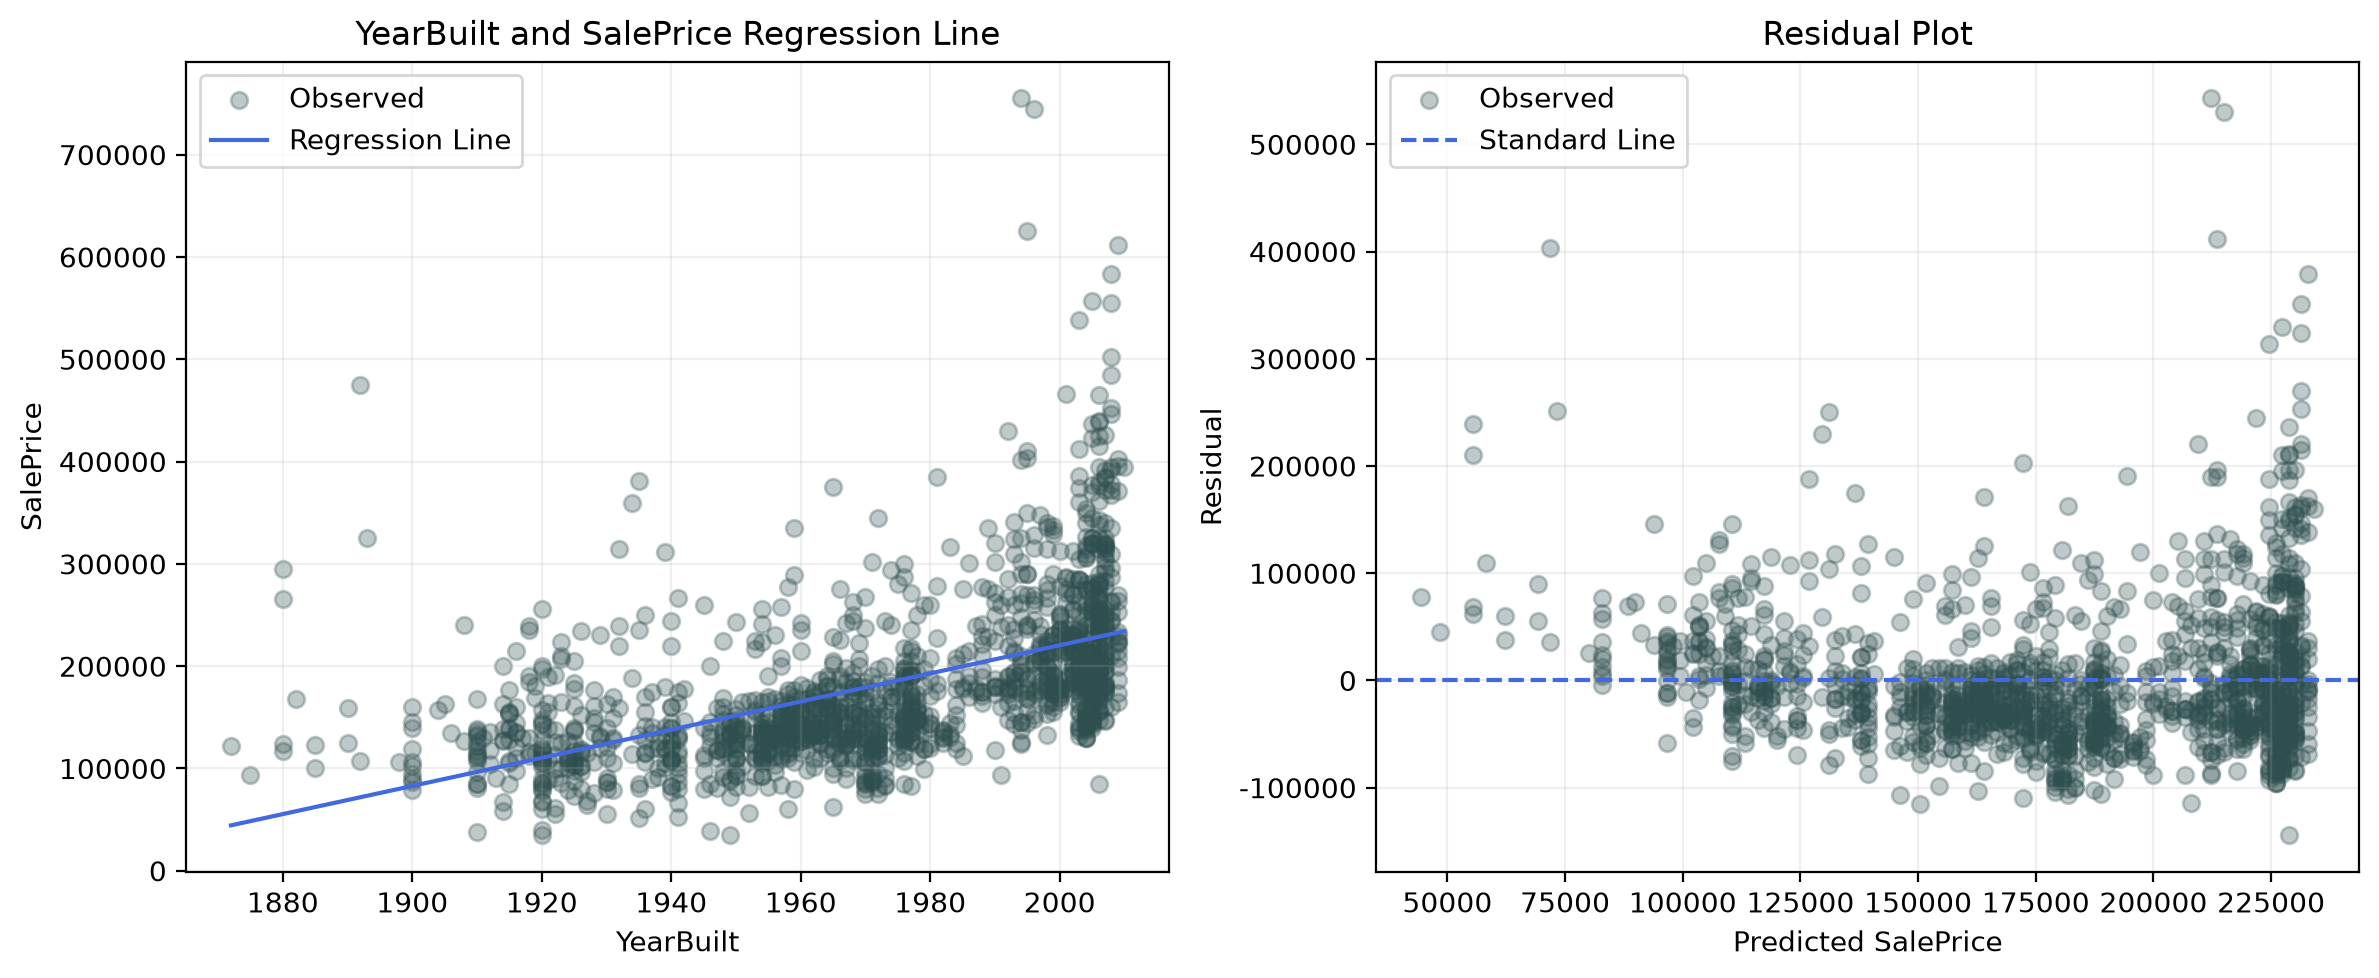

In [4]:
# 여기에 코드를 작성하세요.


# 1. 분석용 데이터 생성
reg_year_df = df[['YearBuilt', 'SalePrice']].dropna()

x = reg_year_df['YearBuilt']
y = reg_year_df['SalePrice']


# x, y 평균
x_mean = x.mean()
y_mean = y.mean()


# 최소제곱법으로 기울기와 절편 직접 계산
beta1 = (
    ((x - x_mean) * (y - y_mean)).sum()
    / ((x - x_mean) ** 2).sum()
)

beta0 = y_mean - beta1 * x_mean

print('[회귀계수]')
print(f'기울기 beta1 : {beta1:.3f}')
print(f'절편 beta0 : {beta0:.3f}')

print('\n[회귀식]')
print(f'SalePrice = {beta0:.3f} + {beta1:.3f} × YearBuilt')


# 2. 예측값과 잔차
y_pred = beta0 + beta1 * x
residual = y - y_pred


# SSE (Sum Squared Error)
SSE = ((y - y_pred) ** 2).sum()

# SST 
SST = ((y - y_mean) ** 2).sum()

# R²
r_squared = 1 - SSE / SST

print('\n[모델 평가]')
print(f'SSE : {SSE:.3f}')
print(f'SST : {SST:.3f}')
print(f'R² : {r_squared:.3f}')

print(f'잔차 평균 : {residual.mean():.3f}')


# 3. 2000년에 건축된 주택 매매가격 예측
pred_2000 = beta0 + beta1 * 2000

print('\n[2000년 건축 주택 매매가격 예측]')
print(f'예상 SalePrice : {pred_2000:,.3f}')


# 4. 시각화
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# 4-1. 산점도 + 회귀직선
ax[0].scatter(x, y, alpha=0.3, color='darkslategray', label='Observed')

x_line = np.linspace(x.min(), x.max(), 100)
y_line = beta0 + beta1 * x_line

ax[0].plot(x_line, y_line, color='royalblue', label='Regression Line')

ax[0].set_xlabel('YearBuilt')
ax[0].set_ylabel('SalePrice')
ax[0].set_title('YearBuilt and SalePrice Regression Line')
ax[0].grid(alpha=0.2)
ax[0].legend()


# 4-2. 잔차 플롯
ax[1].scatter(y_pred, residual, alpha=0.3, color='darkslategray', label='Observed')

ax[1].axhline(y=0, linestyle='--', color='royalblue', label='Standard Line')

ax[1].set_xlabel('Predicted SalePrice')
ax[1].set_ylabel('Residual')
ax[1].set_title('Residual Plot')
ax[1].grid(alpha=0.2)
ax[1].legend()

plt.tight_layout()
plt.show()

### 질문

- 기울기와 절편은 각각 무엇을 의미하나요?   

    `y = aX + b` 라고 가정하면
    - 기울기는 X가 1단위 증가할 때 직선의 예측값이 얼마나 달라지는지 의미한다. 이 모델의 기울기는 1375.373이므로 건축연도가 1년 증가할때 매매 가격은 약 1375.373달러 만큼 증가한다고 나타낼 수 있다.

    - 절편은 X가 0일 때 모델이 예측하는 y값을 의미한다. 이 모델의 절편은 -2,530,308.246이다.

<br>

- $R^2$을 기준으로 모델의 설명력은 어떠한가요?

    - $R^2$은 모델의 설명력을 의미한다.

    - 이 모델의 설명력은 약 27.3%를 나타내므로 높은 설명력을 가지지않는다.

<br>

- 잔차 플롯을 기준으로 모델의 적합성에 주의할 점이 있나요?

    - 적절한 잔차는 0을 중심으로 분포되어있어야 잘 예측한 모델이라고 할 수 있다. 하지만 이 모델의 경우 잔차들의 패턴이 보이지 않아 

    - 중복값, 결측치 등의 이상치를 확인해보아야 한다.

<br>

- 이 모델의 적용 한계 또는 개선 방향을 한 가지 이상 제시하세요.

    - 실제 주택 매매가격은 건축연도뿐만 아니라 OverallQual(주택 전체 품질), GrLivArea(지상층 생활 면적), Neighborhood(지역)등 다양한 요인의 영향을 받을 수 있다. 

    - 따라서 다양한 변수들을 고려해보아야 한다.

---

## 실습 마무리

- 어떤 문제가 있었는가?
- 어떻게 개선했는가?
- 무엇을 근거로 개선되었다고 판단했는가?

$R^2$만 확인했을 때 놓칠 수 있는 점과 잔차 플롯을 추가했을 때 새롭게 확인한 내용을 중심으로 정리하세요.
